# Results — 2D U-Net MS lesion segmentation

Reads the outputs of `src/train.py` and `src/evaluate.py` (run those first, typically on the GPU machine). This notebook only reads `outputs/checkpoints/*_history.json` and `outputs/figures/*.csv`, so it can be run on either machine after `git pull`.

In [1]:
import sys
import json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

CHECKPOINT_DIR = PROJECT_ROOT / "outputs" / "checkpoints"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

## Training curves per fold

Found 5 fold history file(s)


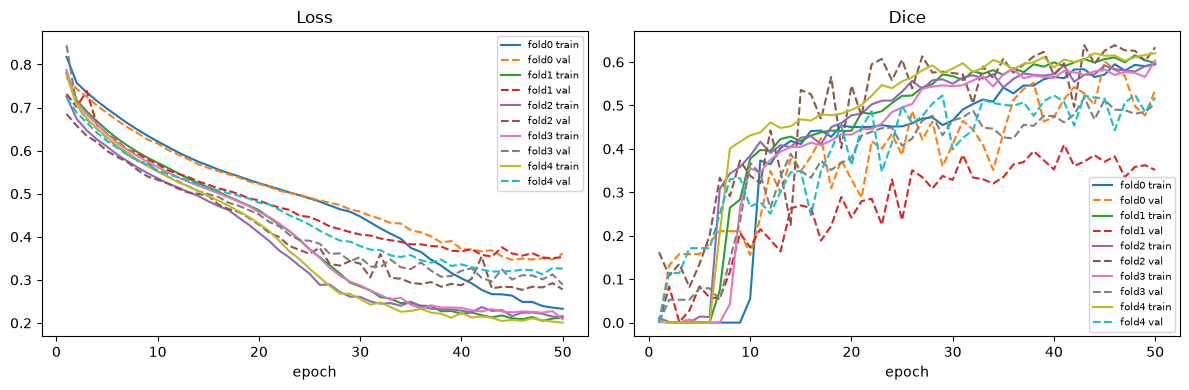

In [2]:
history_files = sorted(CHECKPOINT_DIR.glob("fold*_history.json"))
print(f"Found {len(history_files)} fold history file(s)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for hist_path in history_files:
    fold_label = hist_path.stem.replace("_history", "")
    history = json.loads(hist_path.read_text())
    epochs = [h["epoch"] for h in history]
    axes[0].plot(epochs, [h["train"]["loss"] for h in history], label=f"{fold_label} train")
    axes[0].plot(epochs, [h["val"]["loss"] for h in history], linestyle="--", label=f"{fold_label} val")
    axes[1].plot(epochs, [h["train"]["dice"] for h in history], label=f"{fold_label} train")
    axes[1].plot(epochs, [h["val"]["dice"] for h in history], linestyle="--", label=f"{fold_label} val")

axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend(fontsize=7)
axes[1].set_title("Dice"); axes[1].set_xlabel("epoch"); axes[1].legend(fontsize=7)
fig.tight_layout()

## Metrics table (from `src/evaluate.py`)

In [3]:
by_fold_path = FIGURES_DIR / "metrics_by_fold.csv"
summary_path = FIGURES_DIR / "metrics_summary.csv"

if by_fold_path.exists():
    display(pd.read_csv(by_fold_path))
if summary_path.exists():
    print("\nMean ± std across folds:")
    display(pd.read_csv(summary_path, index_col=0))
else:
    print("Run `python src/evaluate.py` first to generate these files.")

,fold,dice,iou,sensitivity,precision
0,0,0.601848,0.487202,0.621018,0.669955
1,1,0.409622,0.315589,0.397383,0.680978
2,2,0.638633,0.506518,0.667367,0.670208
3,3,0.518664,0.389108,0.599427,0.566028
4,4,0.524655,0.407599,0.638694,0.594899



Mean ± std across folds:


,dice,iou,sensitivity,precision
mean,0.538684,0.421203,0.584778,0.636414
std,0.088366,0.077466,0.107672,0.052275


## Prediction examples

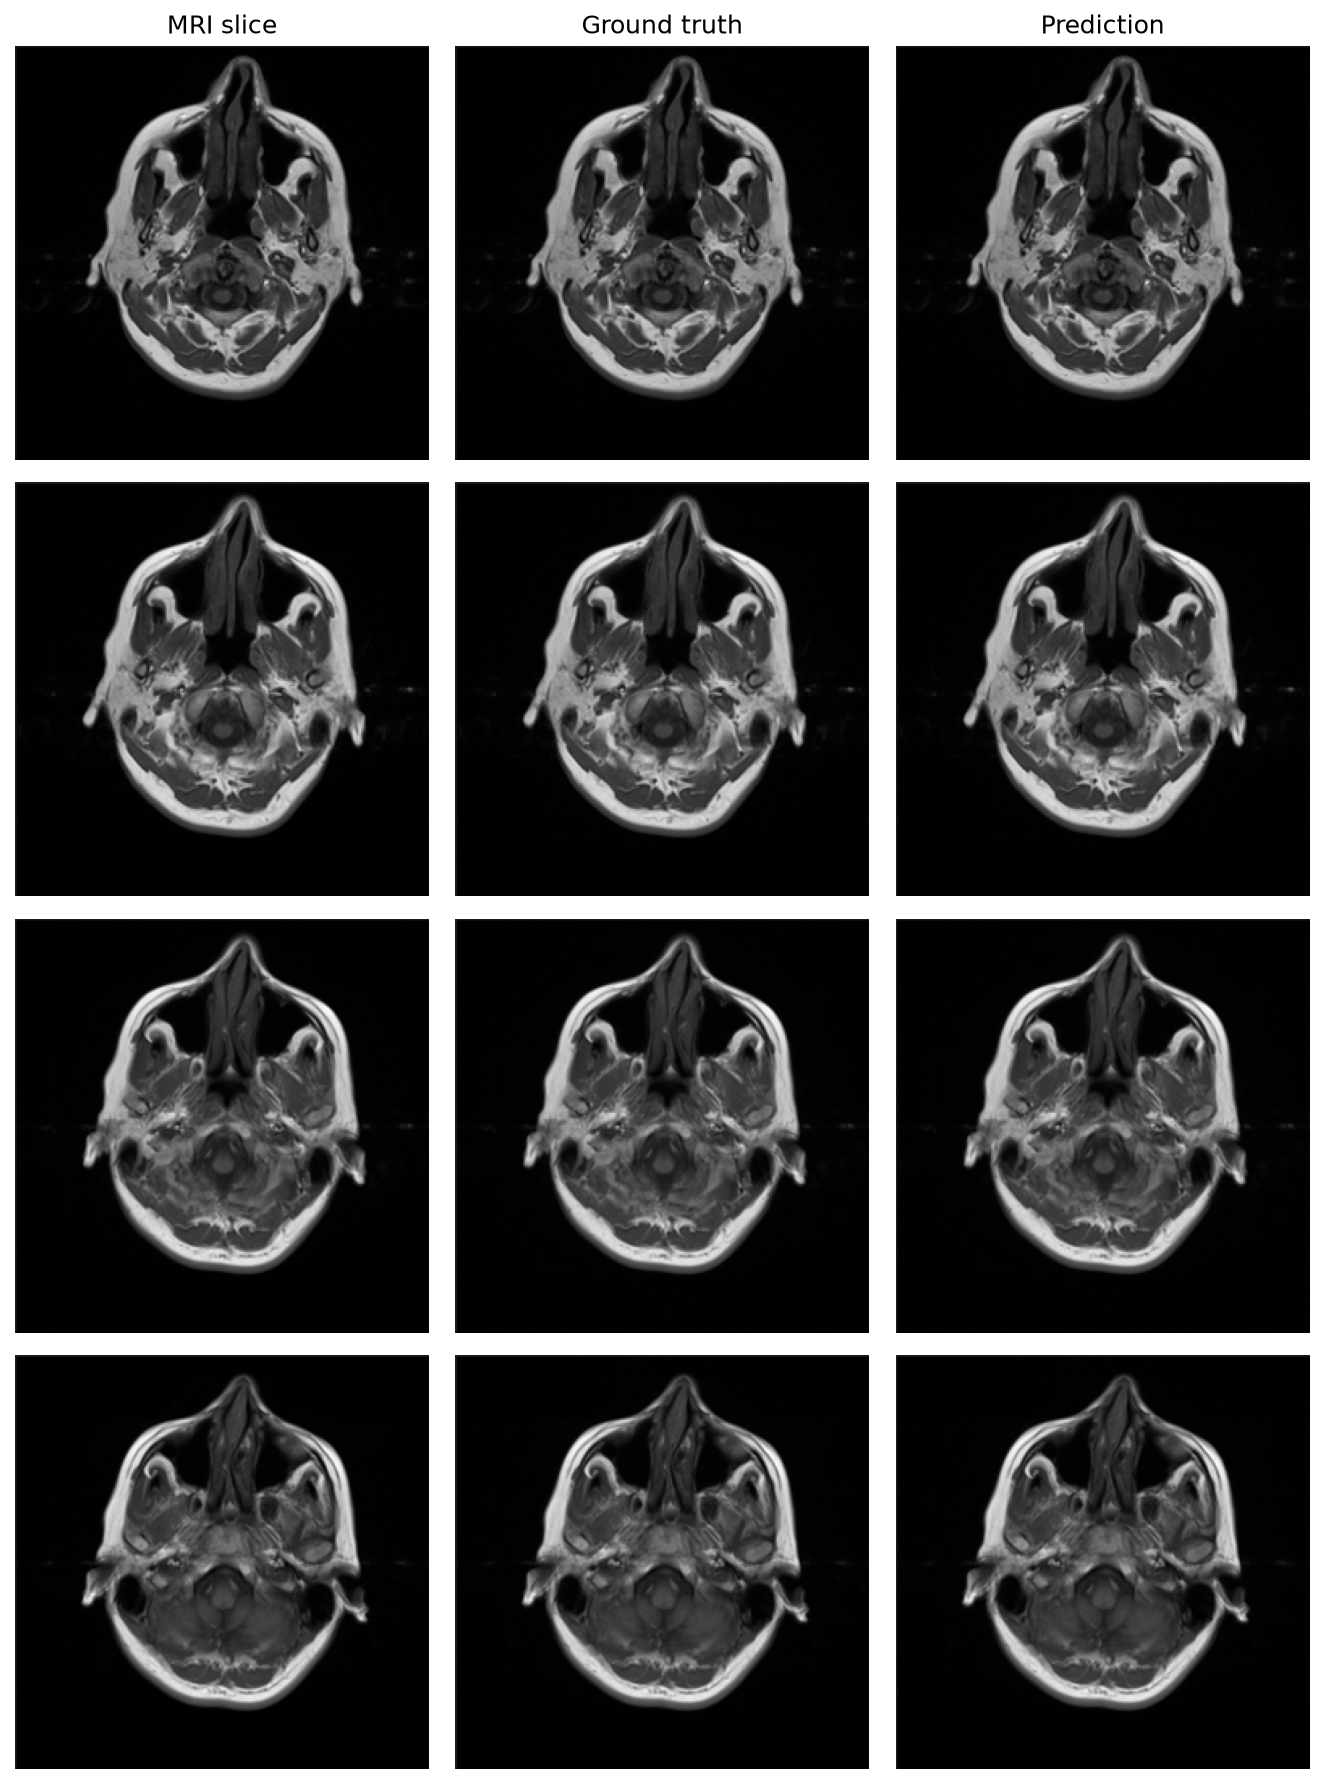

In [4]:
from IPython.display import Image, display as ipy_display

pred_fig_path = FIGURES_DIR / "prediction_examples.png"
if pred_fig_path.exists():
    ipy_display(Image(filename=str(pred_fig_path)))
else:
    print("No prediction figure yet — run src/evaluate.py.")

## Discussion & limitations

- **Sample size**: only 60 patients total; per-fold validation sets are small (~12 patients), so metric variance across folds should be reported and taken seriously rather than a single headline number.
- **Multi-center acquisition**: scans come from 20 different centers (2019-2020), meaning intensity/contrast characteristics vary — the per-volume z-score normalization only partially addresses this; a more thorough harmonization (e.g. histogram matching) could be explored.
- **2D vs 3D**: slice-by-slice segmentation ignores inter-slice spatial context that a 3D model would capture; useful as a fast baseline, but a 3D U-Net is a natural next step for improving boundary/shape accuracy.
- **Class imbalance**: lesion pixels are a small minority even within slices that contain lesions; the Dice+BCE loss partially mitigates this, but per-lesion (not just per-pixel) detection metrics could be added for a more clinically relevant evaluation.